<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/6.wind_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import ee
import geemap
import pandas as pd

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-curuai2')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
floodplain = ee.FeatureCollection('projects/ee-curuai2/assets/lim_varzea') # bacia curuai
floodplain_2 = ee.FeatureCollection('projects/ee-curuai2/assets/bho_otto_nivel2_curuai') #bacia nivel 2
floodplain_2

# Import ERA5 - wind - dataset

ERA5-Land is a reanalysis dataset providing a consistent view of the evolution of land variables over several decades at an enhanced resolution compared to ERA5. ERA5-Land has been produced by replaying the land component of the ECMWF ERA5 climate reanalysis. Reanalysis combines model data with observations from across the world into a globally complete and consistent dataset using the laws of physics. Reanalysis produces data that goes several decades back in time, providing an accurate description of the climate of the past. This dataset includes all 50 variables as available on CDS.

ERA5-Land data is available from 1950 to three months from real-time.

Please consult the ERA5-Land "Known Issues" section. In particular, note that three components of the total evapotranspiration have values swapped as follows:

variable "Evaporation from bare soil" (mars parameter code 228101 (evabs)) has the values corresponding to the "Evaporation from vegetation transpiration" (mars parameter 228103 (evavt)),
variable "Evaporation from open water surfaces excluding oceans (mars parameter code 228102 (evaow)) has the values corresponding to the "Evaporation from bare soil" (mars parameter code 228101 (evabs)),
variable "Evaporation from vegetation transpiration" (mars parameter code 228103 (evavt)) has the values corresponding to the "Evaporation from open water surfaces excluding oceans" (mars parameter code 228102 (evaow)).
The asset is a monthly aggregate of ECMWF ERA5 Land hourly assets which includes both flow and non-flow bands. Flow bands are formed by collecting the first hour's data of the following day for each day of the month and then adding them together, while the non-flow bands are created by averaging all hourly data of the month. The flow bands are labeled with the "_sum" identifier, which approach is different from the monthly data produced by Copernicus Climate Data Store, where flow bands are averaged too.

Monthly aggregates have been pre-calculated to facilitate many applications requiring easy and fast access to the data, when sub-monthly fields are not required.

Precipitation and other flow (accumulated) bands might occasionally have negative values, which doesn't make physical sense. At other times their values might be excessively high.

This problem is due to how the GRIB format saves data: it simplifies or "packs" the data into smaller, less precise numbers, which can introduce errors. These errors get worse when the data varies a lot.

Because of this, when we look at the data for a whole day to compute daily totals, sometimes the highest amount of rainfall recorded at one time can seem larger than the total rainfall measured for the entire day.

11132 meters

Eastward and Northward  component of the 10m wind. It is the horizontal speed of air moving towards the east, at a height of ten meters above the surface of the Earth, in meters per second. Care should be taken when comparing this variable with observations, because wind observations vary on small space and time scales and are affected by the local terrain, vegetation and buildings that are represented only on average in the ECMWF Integrated Forecasting System. This variable can be combined with the V component of 10m wind to give the speed and direction of the horizontal 10m wind.

In [ ]:
wind_col = (ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR")
            .select(['u_component_of_wind_10m','v_component_of_wind_10m']))
# display(wind_col.size().getInfo())

In [ ]:
# display(wind_col.first().getInfo())

# filter collection

In [ ]:
# //Definir o intervalo de tempo
startyear = 1990
endyear = 2024

In [ ]:
# //Definir nossa data inicial e final
startdate = ee.Date.fromYMD(startyear,1,1);
enddate = ee.Date.fromYMD(endyear,12,31);

In [ ]:
# //filterando a coleção
wind_col = wind_col.filterDate(startdate, enddate).filterBounds(floodplain)
print('qtds',wind_col.size().getInfo())

In [ ]:
wind_col_n2 = wind_col.filterDate(startdate, enddate).filterBounds(floodplain_2)
print('qtds',wind_col_n2.size().getInfo())

In [ ]:
scale = wind_col.first().select('v_component_of_wind_10m').projection().nominalScale()

# Wind mean water period by monthly period

In [ ]:
# //Criar uma lista sequencial para ano
years = ee.List.sequence(startyear,endyear);

# //Criar uma lista sequencial para meses
months = ee.List([1,4,7,10])

In [ ]:
# //Calculo da precipitação de cada periodo da série
mean_wind_period =  ee.ImageCollection.fromImages(years.map(lambda y : months.map( lambda m : wind_col.filter(ee.Filter.calendarRange(y,y,'year')).filter(ee.Filter.calendarRange(m,ee.Number(m).add(2),'month')).mean().set({'year': y, 'month': m,'system:time_start': ee.Date.fromYMD(y, m, 1)}).set('timestamp', ee.Date.fromYMD(y, m, 1).format('yyyy-MM-dd')))).flatten() )

display(mean_wind_period.limit(2))

In [ ]:
def mean_wind(img):
  '''receives a wind product returns mean value within the floodplain limits
  as a property of the input image'''


  floodplain = ee.FeatureCollection('projects/ee-curuai2/assets/lim_varzea').geometry()

  scale = img.select('v_component_of_wind_10m').projection().nominalScale()

  stats_u = img.select("u_component_of_wind_10m").reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': floodplain,
    'scale': scale,
    'maxPixels': 1e10
    })
  stats_v = img.select("v_component_of_wind_10m").reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': floodplain,
    'scale': scale,
    'maxPixels': 1e10
    })

  return ee.Feature(floodplain).set({'mean_u__wind':stats_u.get('u_component_of_wind_10m'),
                                     'mean_v__wind':stats_v.get('v_component_of_wind_10m')}).copyProperties(img)

In [ ]:
mean_watershed_wind = ee.FeatureCollection(mean_wind_period.map(mean_wind))
mean_watershed_wind.limit(2)

In [ ]:
mean_watershed_wind.size()

# Wind mean water period by obidos elevation period

In [ ]:
#import period dates
df_period_limits = pd.read_csv('/content/drive/MyDrive/CURUAI_PROCESS/water_period_limits.csv').drop(columns=['Unnamed: 0'])
# df_period_limits['Data'] = pd.to_datetime(df_period_limits['Data'])
df_period_limits

In [ ]:
list_images = []
for i in range(0,len(df_period_limits)-1):
  # print(df_period_limits['Data'][i][0:10])
  # print(df_period_limits['Data'][i+1][0:10])

  image = (wind_col.filter(ee.Filter.date(df_period_limits['Data'][i][0:10],df_period_limits['Data'][i+1][0:10]))
              .mean())
  if int(image.bandNames().length().getInfo()) > 0:
    list_images.append(image
              .set('year', str(df_period_limits['year'][i]))
              .set('month_init', str(df_period_limits['month'][i]))
              .set('month_end', str(df_period_limits['month'][i+1]))
              .set('system:time_start', ee.Date.parse('yyyy-MM-dd',str(df_period_limits['Data'][i][0:10])))
              .set('time_start', str(df_period_limits['Data'][i][0:10]))
              .set('time_finish', str(df_period_limits['Data'][i+1][0:10])))



len(list_images)

In [ ]:
list_images.append(wind_col.filterDate('2024-05-30','2025-01-01').mean()
              .set('year', str(2024))
              .set('month_init', str('05'))
              .set('month_end', str(12))
              .set('system:time_start', ee.Date.parse('yyyy-MM-dd',str('2024-05-30')))
              .set('time_start', str('2024-05-30'))
              .set('time_finish', str('2025-01-01')))


In [ ]:
period_mosaics =  ee.ImageCollection.fromImages(ee.List(list_images))
period_mosaics.size()

In [ ]:
period_mosaics.limit(2)

In [ ]:
def mean_wind(img):
  '''receives a wind product returns mean value within the floodplain limits
  as a property of the input image'''


  geom = ee.FeatureCollection('projects/ee-curuai2/assets/lim_varzea').geometry()

  scale = img.select('v_component_of_wind_10m').projection().nominalScale()

  stats_u = img.select("u_component_of_wind_10m").reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': geom,
    'scale': scale,
    'maxPixels': 1e10
    })
  stats_v = img.select("v_component_of_wind_10m").reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': geom,
    'scale': scale,
    'maxPixels': 1e10
    })

  return ee.Feature(geom).set({'mean_u__wind':stats_u.get('u_component_of_wind_10m'),
                                     'mean_v__wind':stats_v.get('v_component_of_wind_10m')}).copyProperties(img)

def mean_wind_n2(img):
  '''receives a wind product returns mean value within the floodplain limits
  as a property of the input image'''


  geom = ee.FeatureCollection('projects/ee-curuai2/assets/bho_otto_nivel2_curuai').geometry()

  scale = img.select('v_component_of_wind_10m').projection().nominalScale()

  stats_u = img.select("u_component_of_wind_10m").reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': geom,
    'scale': scale,
    'maxPixels': 1e10
    })
  stats_v = img.select("v_component_of_wind_10m").reduceRegion(**{
    'reducer': ee.Reducer.mean(),
    'geometry': geom,
    'scale': scale,
    'maxPixels': 1e10
    })

  return ee.Feature(geom).set({'mean_u__wind':stats_u.get('u_component_of_wind_10m'),
                                     'mean_v__wind':stats_v.get('v_component_of_wind_10m')}).copyProperties(img)

In [ ]:
mean_watershed_wind_cota = ee.FeatureCollection(period_mosaics.map(mean_wind))
mean_watershed_wind_cota.limit(2)

In [ ]:
mean_watershed_wind_cota_n2 = ee.FeatureCollection(period_mosaics.map(mean_wind_n2))
mean_watershed_wind_cota_n2.limit(2)

<Axes: xlabel='time_start', ylabel='mean_u__wind'>

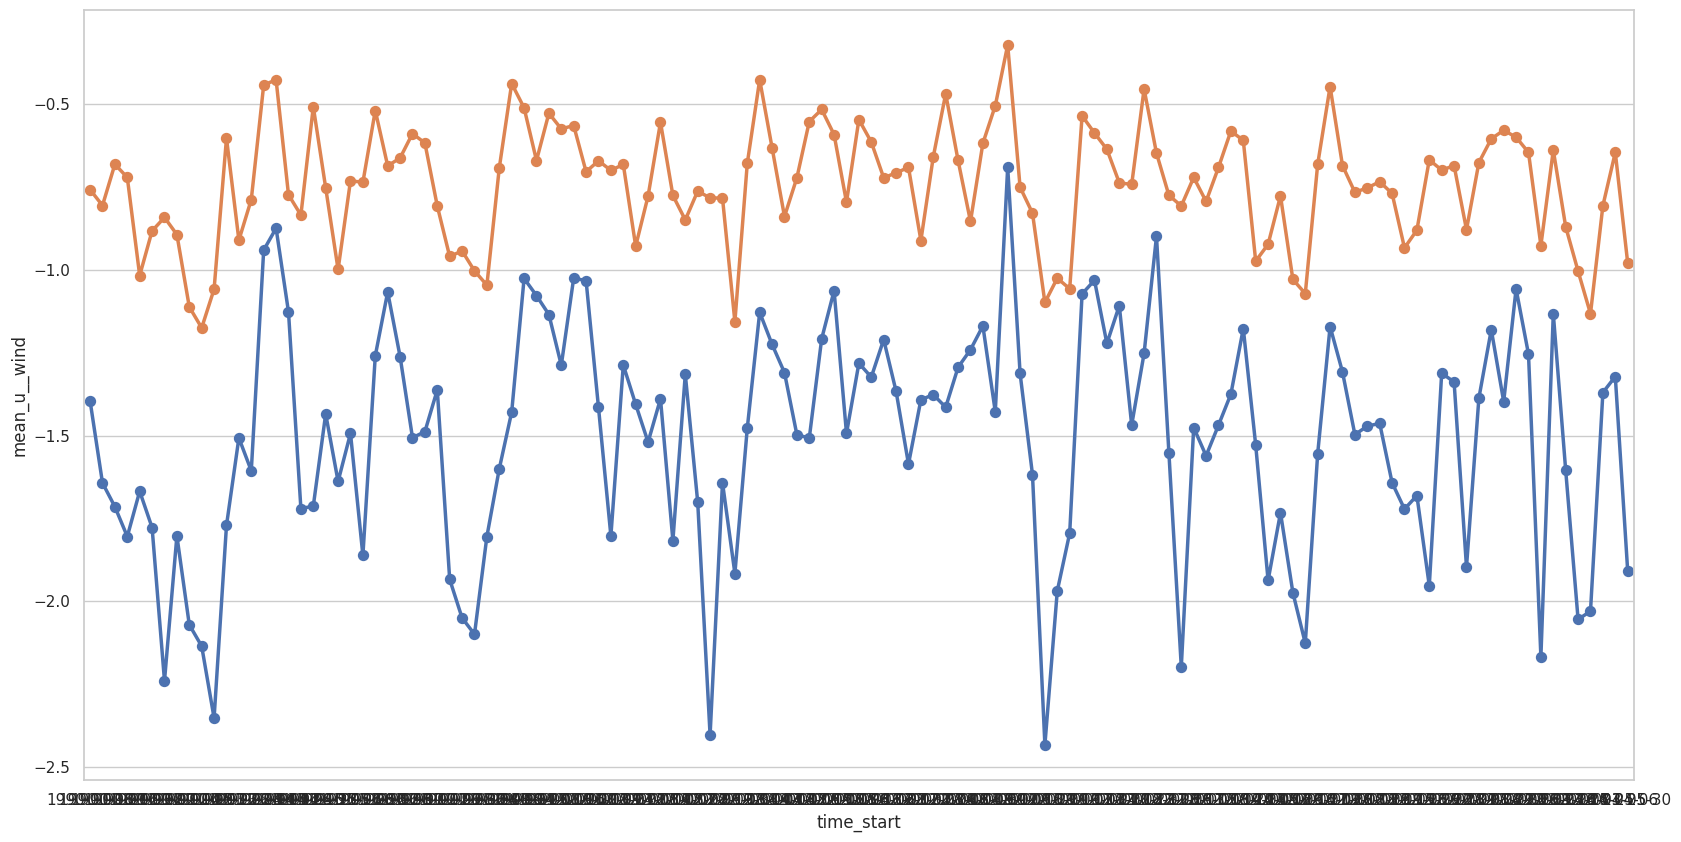

In [21]:
import seaborn as sns
df = geemap.ee_to_df(mean_watershed_wind_cota)
dfN2 = geemap.ee_to_df(mean_watershed_wind_cota_n2)
#comparar dados = seguem o mesmo padrão, aproximadamente
sns.set_theme(style="whitegrid",rc={'figure.figsize':(20,10)})
sns.pointplot(data=df,x = df['time_start'],y = df['mean_u__wind'], linewidth=2.5)
sns.pointplot(data=dfN2,x = dfN2['time_start'],y = dfN2['mean_u__wind'], linewidth=2.5)
# mostra que dados das duas estações tem comportamento similar, apesar dos valores de curuai serem maiores que o de obidos.


# Export Data

In [ ]:
# geemap.ee_to_csv(mean_watershed_wind_cota, '/content/drive/MyDrive/CURUAI_PROCESS/mean_watershed_wind_cota.csv')
geemap.ee_to_csv(mean_watershed_wind_cota, '/content/drive/MyDrive/CURUAI_PROCESS/mean_watershed_wind_cota.csv')
geemap.ee_to_csv(mean_watershed_wind_cota_n2, '/content/drive/MyDrive/CURUAI_PROCESS/mean_watershed_wind_cotaN2.csv')

In [ ]:
geemap.ee_to_csv(mean_watershed_wind, '/content/drive/MyDrive/CURUAI_PROCESS/mean_watershed_wind.csv')